In [26]:
# local library
from propagation import (
    KemenyYoung,
    lpa,
    run_label_propagation,
    set_labels,
)
# python libraries
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import random
from joblib import Parallel, delayed
#import community.community_louvain as community_louvain
#import upsetplot
#import matplotlib.patches as mpatches


In [9]:
from pathlib import Path

project_root = Path.cwd()
data_folder = project_root / "data"
graph_path = data_folder / "modified_graph.gml"

In [18]:
G = nx.read_gml(graph_path)
print("Number of nodes in the graph:", G.number_of_nodes())
print("Number of edges in the graph:", G.number_of_edges())

Number of nodes in the graph: 3240
Number of edges in the graph: 7254


In [46]:
# Load, filter, and prepare experiment data
data_folder = Path.cwd() / "data"
data_files = {
    "liu": data_folder / "liu.txt",
    "gonzalez": data_folder / "gonzalez.txt",
    "comets": data_folder / "COMETS.txt",
    "mth": data_folder / "MTH.txt",
    "pietzner": data_folder / "pietznzer.txt",
    "estelle": data_folder / "Estelle.txt",
}

valid_nodes = set(G.nodes())
experiments = []

for name, file_path in data_files.items():
    data_list = pd.read_csv(file_path).HUMAN1_ID.tolist()
    filtered_list = [node for node in data_list if node in valid_nodes]
    print(f"{name.capitalize()}: {len(filtered_list)}/{len(data_list)} nodes valid")
    experiments.append((name, filtered_list))

Liu: 263/1002 nodes valid
Gonzalez: 241/902 nodes valid
Comets: 204/827 nodes valid
Mth: 176/682 nodes valid
Pietzner: 190/760 nodes valid
Estelle: 420/1527 nodes valid


In [47]:
# Define a function that runs label propagation for each dataset
def run_experiment(name, exp_list):
    result = run_label_propagation(G, exp_list)
    return name, result  # Return the name and the result for easier tracking

In [48]:
# Run label propagation for each dataset
results = [run_experiment(name, exp) for name, exp in experiments]

In [49]:
results_dict = {name: result for name, result in results}

In [ ]:
y = [sum(results_dict[i].values()) for i in results_dict.keys()]

[549, 473, 402, 342, 379, 809]

In [54]:
names = results_dict.keys()

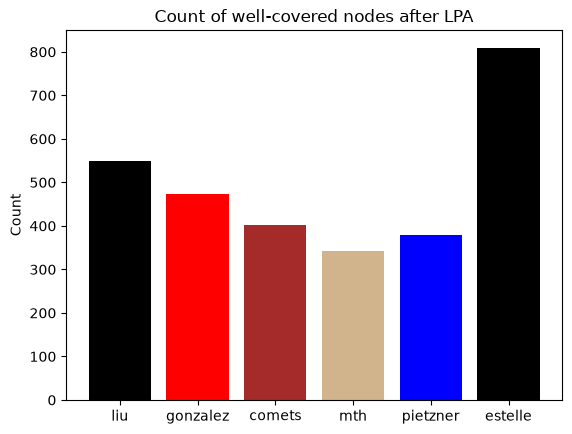

In [56]:
# Step 3: Generate colors for each bar
colors = ['black', 'red', 'brown', '#D2B48C', 'blue']  # '#D2B48C' is light brown

# Step 4: Create bar plot with different colors
plt.bar(names, y, color=colors)
plt.ylabel('Count')
plt.title('Count of well-covered nodes after LPA')
#plt.savefig('figs/LPA.png')
plt.show()

In [57]:
ky = KemenyYoung(G)